In [2]:
import pandas as pd
from google.cloud import bigquery
from google.oauth2 import service_account

credentials = service_account.Credentials.from_service_account_file("key.json") # lokalizacja pobranego klucza z punktu 1.4.

client = bigquery.Client(credentials=credentials, project=credentials.project_id)

In [3]:
query = """

select r20_21.*, stations.*

from (

select *
from `bigquery-public-data.noaa_gsod.gsod2020`

union all

select *
from `bigquery-public-data.noaa_gsod.gsod2021`

) as r20_21
join `bigquery-public-data.noaa_gsod.stations` as stations on r20_21.stn = stations.usaf and r20_21.wban = stations.wban
"""

query_job = client.query(query)
query_result = query_job.result()
# weather and stations
dfwas = query_result.to_dataframe()

Część 1

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = dfwas.copy()
data["date"] = pd.to_datetime(data["date"], errors="coerce")
data["month"] = data["date"].dt.month
data["mxpsd"] = pd.to_numeric(data["mxpsd"], errors="coerce")

missing_codes = {
    "temp": 9999.9,
    "max": 9999.9,
    "min": 9999.9,
    "dewp": 9999.9,
    "slp": 9999.9,
    "stp": 9999.9,
    "visib": 999.9,
    "wdsp": 999.9,
    "mxpsd": 999.9,
    "gust": 999.9,
    "prcp": 99.99
}

for col, code in missing_codes.items():
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")
        data[col] = data[col].replace(code, np.nan)

sns.set(style="whitegrid")

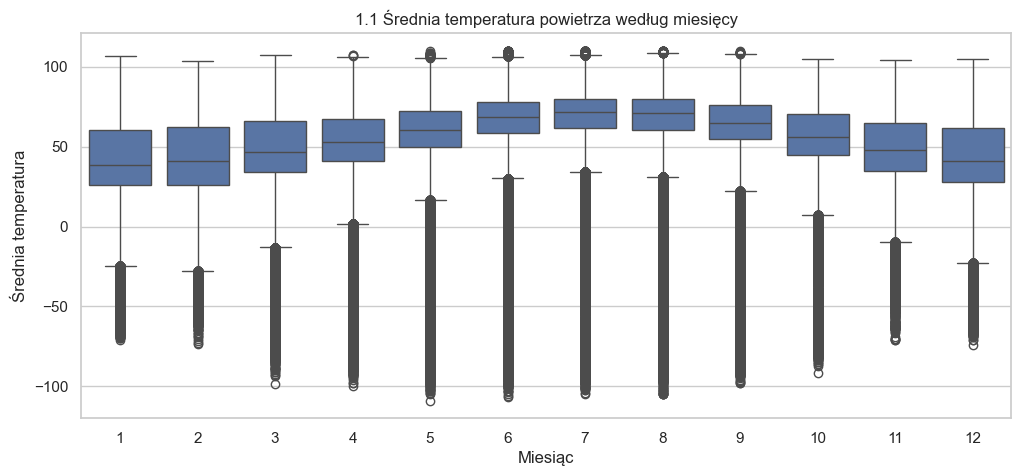

In [5]:
#1.1
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="temp", data=data)
plt.title("1.1 Średnia temperatura powietrza według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Średnia temperatura")
plt.show()

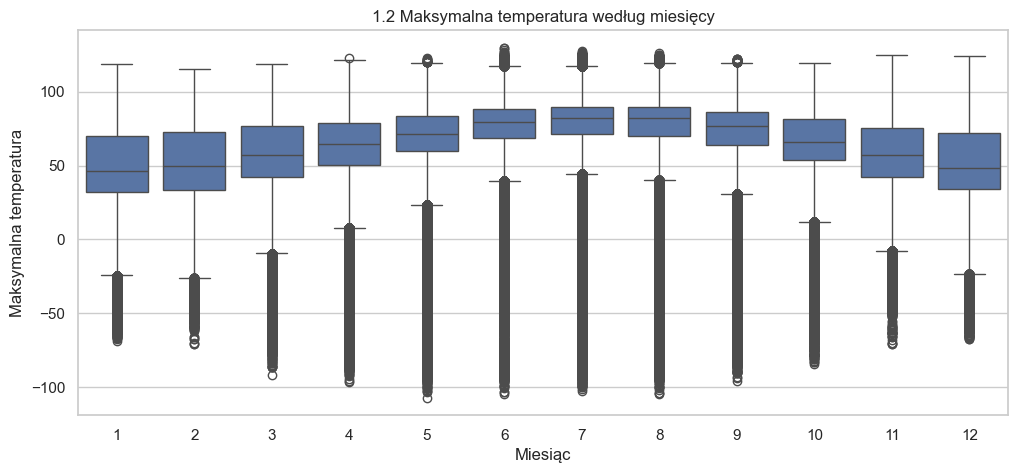

In [6]:
#1.2
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="max", data=data)
plt.title("1.2 Maksymalna temperatura według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Maksymalna temperatura")
plt.show()

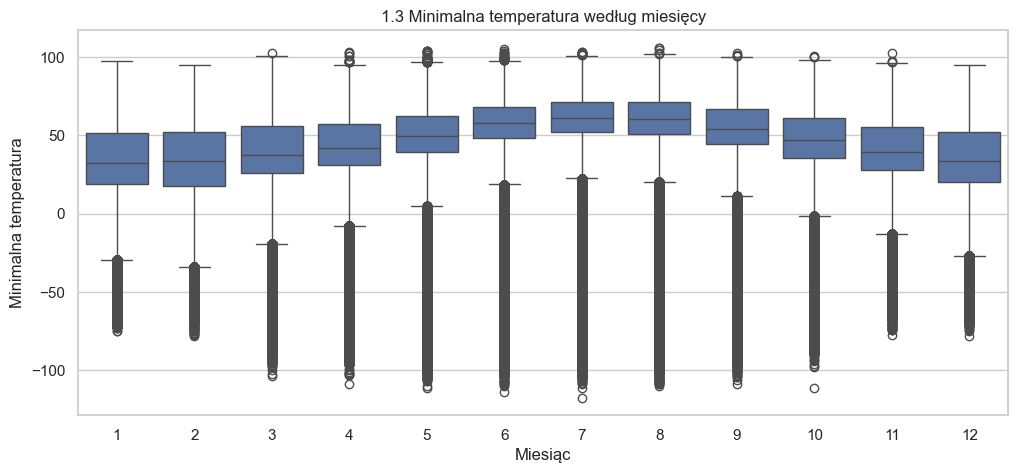

In [7]:
#1.3
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="min", data=data)
plt.title("1.3 Minimalna temperatura według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Minimalna temperatura")
plt.show()

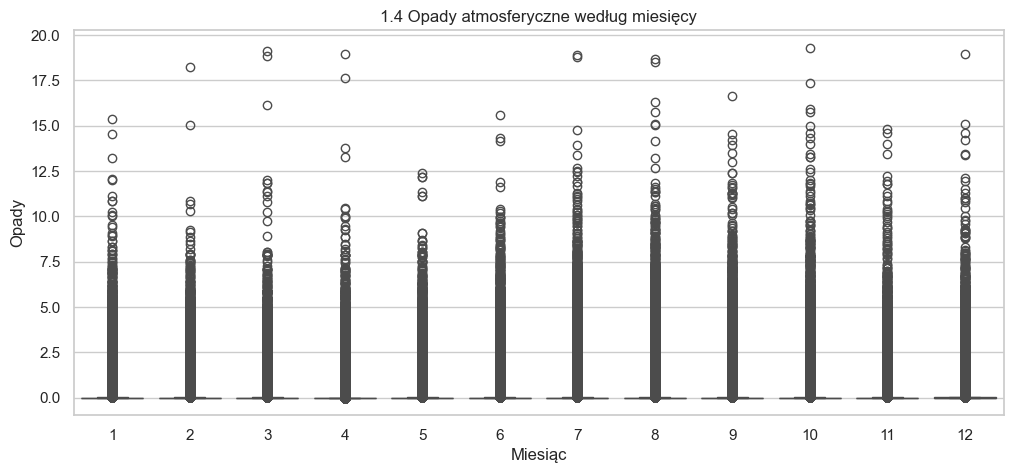

In [8]:
#1.4
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="prcp", data=data)
plt.title("1.4 Opady atmosferyczne według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Opady")
plt.show()

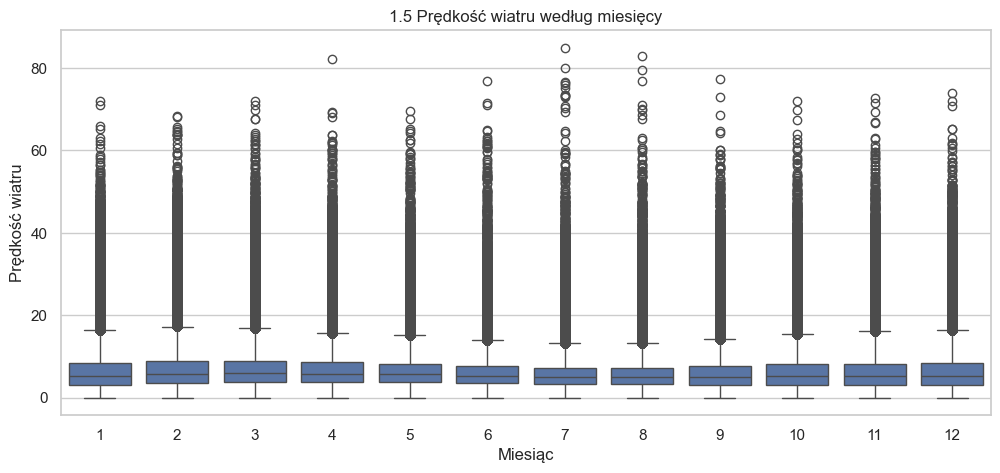

In [9]:
#1.5
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="wdsp", data=data)
plt.title("1.5 Prędkość wiatru według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Prędkość wiatru")
plt.show()

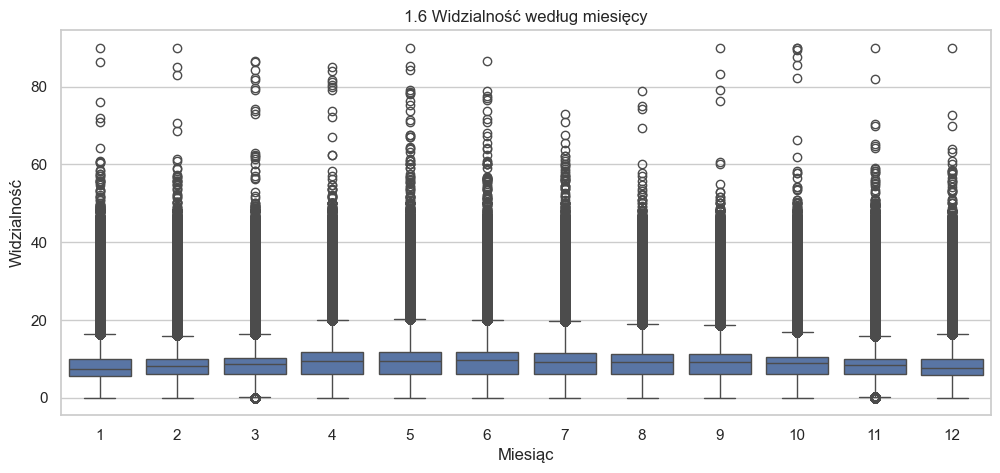

In [10]:
#1.6
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="visib", data=data)
plt.title("1.6 Widzialność według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Widzialność")
plt.show()

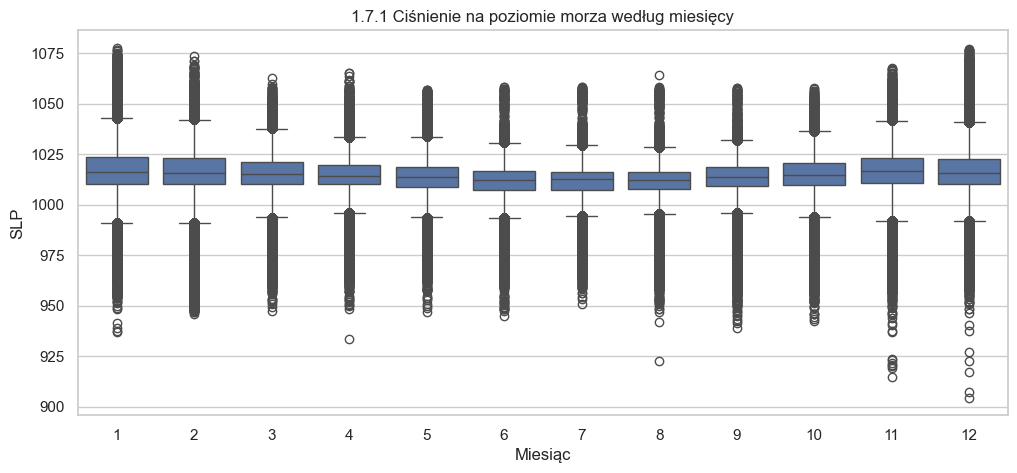

In [11]:
#1.7.1
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="slp", data=data)
plt.title("1.7.1 Ciśnienie na poziomie morza według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("SLP")
plt.show()

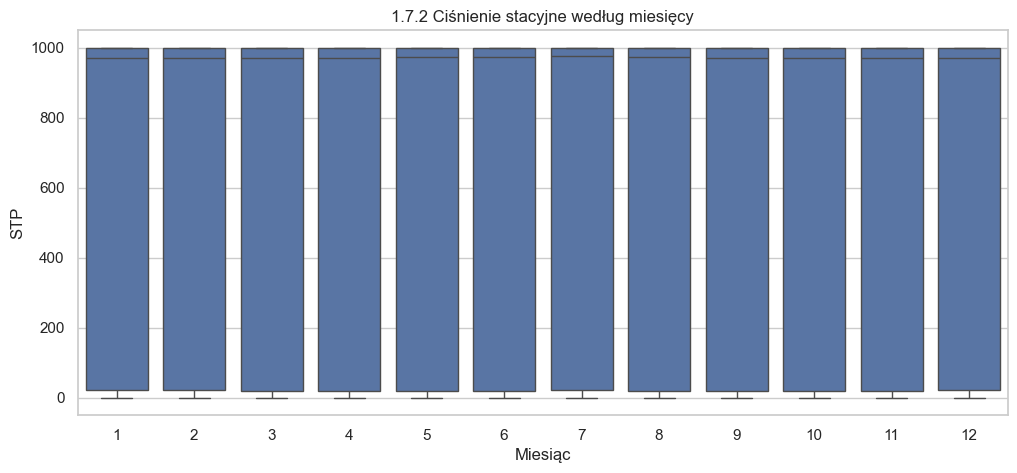

In [12]:
#1.7.2
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="stp", data=data)
plt.title("1.7.2 Ciśnienie stacyjne według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("STP")
plt.show()

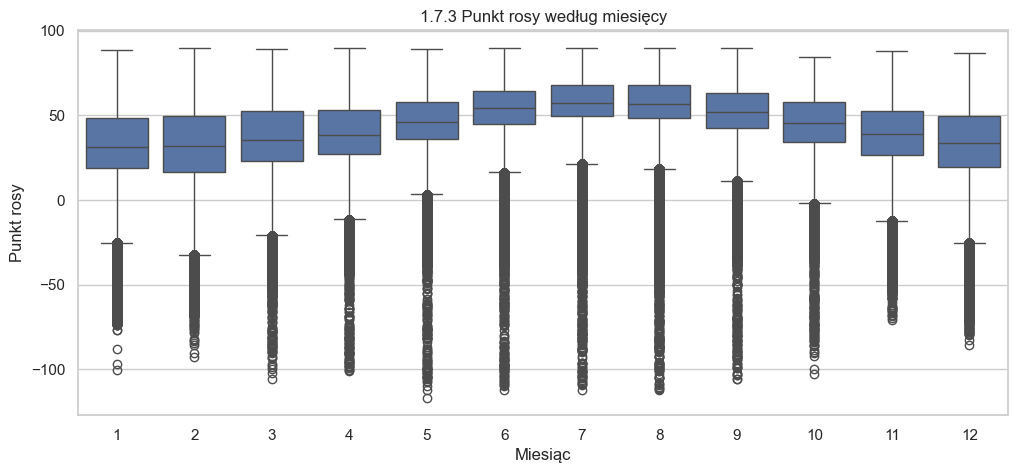

In [13]:
#1.7.3
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="dewp", data=data)
plt.title("1.7.3 Punkt rosy według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Punkt rosy")
plt.show()

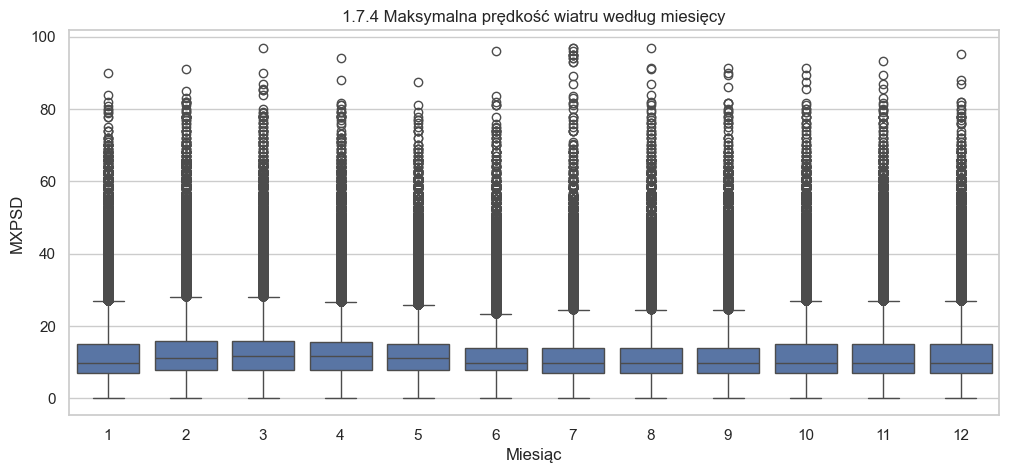

In [14]:
#1.7.4
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="mxpsd", data=data)
plt.title("1.7.4 Maksymalna prędkość wiatru według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("MXPSD")
plt.show()

Część 2

In [15]:
#średnia temperatura oraz prędkość wiatru

if 'month' not in data.columns:
    data["month"] = data["date"].dt.month

zmienne_do_analizy = ["temp", "wdsp"]

for col in zmienne_do_analizy:
    print(col)
    for month in sorted(data["month"].unique()):
        monthly_data = data[data["month"] == month][col].dropna()

        Q1 = monthly_data.quantile(0.25)
        Q3 = monthly_data.quantile(0.75)
        IQR = Q3 - Q1

        min_normal = Q1 - 1.5 * IQR
        max_normal = Q3 + 1.5 * IQR

        outliers_lower = []
        outliers_upper = []
        for md in monthly_data:
            if md < min_normal:
                outliers_lower.append(md)
            elif md > max_normal:
                outliers_upper.append(md)

        print(f"Miesiąc {month}: Znaleziono {len(outliers_lower) + len(outliers_upper)} outlierów (Zakres: {min_normal:.4f} do {max_normal:.4f})")

        if len(outliers_lower):
            print(f"Min: {min(outliers_lower)}")

        if len(outliers_upper):
            print(f"Max: {max(outliers_upper)}")

# po prześledzeniu wyników wydaje się, że outliery to wartości skrajne wynikające z rzeczywistych zjawisk pogodowych.
# na podstawie przeprowadzonej analizy postanowiłem pozostawić je w zbiorze danych.

temp
Miesiąc 1: Znaleziono 11526 outlierów (Zakres: -24.8500 do 111.5500)
Min: -71.0
Miesiąc 2: Znaleziono 6885 outlierów (Zakres: -28.0000 do 116.0000)
Min: -73.6
Miesiąc 3: Znaleziono 9467 outlierów (Zakres: -13.1000 do 113.3000)
Min: -98.3
Miesiąc 4: Znaleziono 7677 outlierów (Zakres: 1.8000 do 106.6000)
Min: -99.6
Max: 107.3
Miesiąc 5: Znaleziono 5613 outlierów (Zakres: 16.4500 do 105.6500)
Min: -109.0
Max: 110.0
Miesiąc 6: Znaleziono 5484 outlierów (Zakres: 30.0500 do 106.4500)
Min: -106.9
Max: 110.0
Miesiąc 7: Znaleziono 6869 outlierów (Zakres: 34.4000 do 107.2000)
Min: -104.8
Max: 110.0
Miesiąc 8: Znaleziono 4663 outlierów (Zakres: 31.2000 do 108.8000)
Min: -105.0
Max: 110.0
Miesiąc 9: Znaleziono 3813 outlierów (Zakres: 22.4000 do 108.0000)
Min: -98.1
Max: 109.6
Miesiąc 10: Znaleziono 4880 outlierów (Zakres: 7.0500 do 108.2500)
Min: -91.9
Miesiąc 11: Znaleziono 6500 outlierów (Zakres: -9.8000 do 109.4000)
Min: -70.9
Miesiąc 12: Znaleziono 11047 outlierów (Zakres: -23.1000 do 112

Część 3

In [28]:
data = dfwas.copy()

data["date"] = pd.to_datetime(data["date"], errors="coerce")

print(data.dtypes)

stn                             object
wban                            object
date                    datetime64[ns]
year                            object
mo                              object
da                              object
temp                           float64
count_temp                       Int64
dewp                           float64
count_dewp                       Int64
slp                            float64
count_slp                        Int64
stp                            float64
count_stp                        Int64
visib                          float64
count_visib                      Int64
wdsp                            object
count_wdsp                      object
mxpsd                           object
gust                           float64
max                            float64
flag_max                        object
min                            float64
flag_min                        object
prcp                           float64
flag_prcp                

In [29]:
#3.2
weather_cols = ["temp", "max", "min", "prcp", "wdsp", "visib", "slp", "stp", "dewp", "mxpsd"]

for col in weather_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

if "temp" in data.columns:
    data["temp"] = data["temp"].replace(9999.9, np.nan)
if "max" in data.columns:
    data["max"] = data["max"].replace(9999.9, np.nan)
if "min" in data.columns:
    data["min"] = data["min"].replace(9999.9, np.nan)
if "dewp" in data.columns:
    data["dewp"] = data["dewp"].replace(9999.9, np.nan)
if "slp" in data.columns:
    data["slp"] = data["slp"].replace(9999.9, np.nan)
if "stp" in data.columns:
    data["stp"] = data["stp"].replace(9999.9, np.nan)

if "visib" in data.columns:
    data["visib"] = data["visib"].replace(999.9, np.nan)
if "wdsp" in data.columns:
    data["wdsp"] = data["wdsp"].replace(999.9, np.nan)
if "mxpsd" in data.columns:
    data["mxpsd"] = data["mxpsd"].replace(999.9, np.nan)

if "prcp" in data.columns:
    data["prcp"] = data["prcp"].replace(99.99, np.nan)

In [30]:
#3.1
missing_summary = pd.DataFrame({
    "liczba_brakow": data.isna().sum(),
    "procent_brakow": round(data.isna().sum() / len(data) * 100, 2)
})

missing_summary = missing_summary.sort_values("liczba_brakow", ascending=False)
missing_summary

,liczba_brakow,procent_brakow
state,6207545,76.45
flag_min,4913008,60.51
flag_max,4786959,58.96
call,3926108,48.35
slp,2794527,34.42
visib,2169612,26.72
flag_prcp,604290,7.44
prcp,604290,7.44
mxpsd,462639,5.70
dewp,395050,4.87


In [31]:
#3.3
data = data.sort_values("date").copy()

selected_cols = ["wdsp", "prcp"]

data_mean = data.copy()
data_median = data.copy()
data_interp = data.copy()

# imputacja średnią
for col in selected_cols:
    data_mean[col] = data_mean[col].fillna(data_mean[col].mean())

# imputacja medianą
for col in selected_cols:
    data_median[col] = data_median[col].fillna(data_median[col].median())

#interpolacja w czasie
data_interp = data_interp.set_index("date")

for col in selected_cols:
    data_interp[col] = data_interp[col].interpolate(method="time")

data_interp = data_interp.reset_index()

In [37]:
#3.4
for col in selected_cols:
    print(f"\n===== {col.upper()} =====")

    print("\nOryginalne dane:")
    print(data[col].describe())

    print("\nPo imputacji średnią:")
    print(data_mean[col].describe())

    print("\nPo imputacji medianą:")
    print(data_median[col].describe())

    print("\nPo interpolacji w czasie:")
    print(data_interp[col].describe())


===== WDSP =====

Oryginalne dane:
count    7.797877e+06
mean     6.340804e+00
std      4.434327e+00
min      0.000000e+00
25%      3.400000e+00
50%      5.300000e+00
75%      8.200000e+00
max      8.490000e+01
Name: wdsp, dtype: float64

Po imputacji średnią:
count    8.119543e+06
mean     6.340804e+00
std      4.345604e+00
min      0.000000e+00
25%      3.500000e+00
50%      5.500000e+00
75%      8.000000e+00
max      8.490000e+01
Name: wdsp, dtype: float64

Po imputacji medianą:
count    8.119543e+06
mean     6.299571e+00
std      4.350343e+00
min      0.000000e+00
25%      3.500000e+00
50%      5.300000e+00
75%      8.000000e+00
max      8.490000e+01
Name: wdsp, dtype: float64

Po interpolacji w czasie:
count    8.119543e+06
mean     6.343034e+00
std      4.434222e+00
min      0.000000e+00
25%      3.400000e+00
50%      5.400000e+00
75%      8.200000e+00
max      8.490000e+01
Name: wdsp, dtype: float64

===== PRCP =====

Oryginalne dane:
count    7.515253e+06
mean     7.583993e-02

Część 4

In [19]:
# Obliczenia statystyczne (m.in. średnia, mediana, moda, odchylenie standardowe) pozwalają na zrozumienie rozkładu danych oraz na identyfikację ewentualnych anomalii lub nietypowych wartości.

# 4.1. średnia temperatura, opady i prędkość wiatru dla co najmniej 10 wybranych krajów lub stacji w wybranym miesiącu,


# "PL": "Poland",
# "QA": "Qatar",
# "RI": "Serbia",
# "SP": "Spain",
# "SZ": "Switzerland",
# 'IR': 'iran (islamic republic of)',
# "US": "United States of America",
# 'ch': 'china, mainland',
# "CI": "Chile",
# "RS": "Russian Federation",

countries_to_check = ["PL", "QA", "RI", "SP", "SZ", "IR", "US", "CH", "CI", "RS"]

df_lip = data[(data['month'] == 7) & (data['country'].isin(countries_to_check))]
df_4_1 = df_lip.groupby('country')[['temp', 'prcp', 'wdsp']].mean().reset_index()

print(f"\n4.1. Średnie wartości dla lipca\n {df_4_1}:")

# 4.2. średnia zmiana temperatury i opadów dla co najmniej 10 wybranych krajów lub stacji w wybranym miesiącu,

data = data.sort_values(['stn', 'date'])
data['temp_change'] = data.groupby('stn')['temp'].diff()
data['prcp_change'] = data.groupby('stn')['prcp'].diff()

df_4_2 = df_lip.groupby('country')[['temp_change', 'prcp_change']].mean().reset_index()

print(f"\n4.2. Średnia dzienna zmiana w lipcu :\n{df_4_2}:")


# 4.3. mediana temperatury, opadów i prędkości wiatru dla co najmniej 10 wybranych krajów lub stacji w wybranym miesiącu,
df_4_3 = df_lip.groupby('country')[['temp', 'prcp', 'wdsp']].median().reset_index()

print(f"\n4.3. Mediana wartości dla lipca \n{df_4_3}:")

# 4.4. odchylenie standardowe temperatury, opadów i prędkości wiatru,
df_4_4 = df_lip[['temp', 'prcp', 'wdsp']].std()
print(f"\n4.4. Odchylenie standardowe: \n{df_4_4}:")

# 4.5. minimalna, średnia i maksymalna temperatury, opadów i prędkości wiatru dla co najmniej 10 wybranych krajów,
df_4_5 = df_lip.groupby('country').agg({
    'temp': ['min', 'mean', 'max'],
    'prcp': ['min', 'mean', 'max'],
    'wdsp': ['min', 'mean', 'max']
})
print(f"\n4.5. Zestawienie Min/Średnia/Max: \n{df_4_5}:")


# Skorzystaj ze swojego połączonego zbioru danych (pogoda + rolnictwo) i oblicz średnią temperaturę oraz sumę opadów w wybranym roku dla co najmniej 10 krajów, a następnie porównaj te wartości z produkcją lub plonem wybranej rośliny w tych krajach. Spróbuj ocenić, czy można zauważyć zależność pomiędzy warunkami pogodowymi a produkcją rolną.

df_4_6 = pd.read_csv('df_merged.csv')
df_4_6 = df_4_6[df_4_6['country'].isin(countries_to_check) & (df_4_6['year'] == 2021) & (df_4_6['Item'] == 'Rye') &
                (df_4_6['Unit'] == 'kg/ha')]
sf4_6 = df_4_6.groupby('country')[['temp', 'prcp', 'Value']].mean()


# Przygotuj wykresy w celu porównania otrzymanych wyników. Pamiętaj o ich czytelności (typ wykresu, tytuł wykresu, podpisy osi, odpowiednie zakresy osi, itp.). Przeanalizuj otrzymane wizualizacje.
fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)

# temp
axes[0].bar(sf4_6.index, sf4_6['temp'], color='orange', alpha=0.8)
axes[0].set_title('Średnia temperatura roczna w 2021 r.', fontsize=14)
axes[0].set_ylabel('Temperatura [°F]', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Opady
axes[1].bar(sf4_6.index, sf4_6['prcp'], color='skyblue', alpha=0.8)
axes[1].set_title('Średnie opady atmosferyczne w 2021 r.', fontsize=14)
axes[1].set_ylabel('Opady [cale]', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

#Żyt0
axes[2].bar(sf4_6.index, sf4_6['Value'], color='forestgreen', alpha=0.8)
axes[2].set_title('Plon żyta (Rye) w 2021 r.', fontsize=14)
axes[2].set_ylabel('Plon [kg/ha]', fontsize=12)
axes[2].set_xlabel('Kraj (Kod ISO)', fontsize=12)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

# Dopasowanie układu
plt.tight_layout()
plt.show()


KeyError: 'month'